# Retrieval diagnostics + recovered abundances (POSEIDON)


In [73]:
from __future__ import annotations

import re
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib as mpl

mpl.rcParams["font.family"] = "serif"
mpl.rcParams["mathtext.fontset"] = "stix"
mpl.rcParams["axes.unicode_minus"] = False


# -----------------------------
# Paths (edit as needed)
# -----------------------------
CHI2_PATH = Path(r"chi2_log.csv")
TIMES_PATH = Path(r"Times")

POSEIDON_BASE_DIR = Path(r"POSEIDON_output/Trappist-1e/retrievals")
POSEIDON_OUT_CSV = POSEIDON_BASE_DIR / "retrieved_gases_recovered_minmax.csv"


# -----------------------------
# Plot style constants
# -----------------------------
PALETTE = {
    "uncontam": "#E9C46A",
    "contam": "#2A9D8F",
    "recon": "#E76F51",
}
MARKERS = {"uncontam": "o", "contam": "s", "recon": "D"}
LEGEND_LABELS = {"uncontam": "Chem", "contam": "Cont + Chem", "recon": "G-DAE + Chem"}

MODEL_ORDER = ["uncontam", "contam", "recon"]


## 1) Load and parse retrieval diagnostics

We parse model metadata from:
- `chi2_log.csv` → `model_name` (contains model type, transits, spot/facula fractions)
- `Times`        → `N_T`, `Mode`, `ffacfspot`, and runtime

Then we merge both on: `(n_transits, model_type, spot_fraction, facula_fraction)`.


In [74]:
MODEL_TYPE_RE = re.compile(r"(contam|recon|uncontam)")
N_TRANSITS_RE = re.compile(r"(\d+)T")
SPOT_RE = re.compile(r"(\d+\.\d+)spot")
FAC_RE = re.compile(r"(\d+\.\d+)fac")


def parse_model_name(model_name: str) -> Tuple[int | None, str | None, float, float]:
    """
    Parse metadata encoded in `model_name`.

    Expected patterns include tokens like:
    - "10T"
    - "contam" / "recon" / "uncontam"
    - "0.00spot"
    - "0.00fac"

    Returns
    -------
    n_transits, model_type, spot_fraction, facula_fraction
    """
    n_transits_match = N_TRANSITS_RE.search(model_name)
    n_transits = int(n_transits_match.group(1)) if n_transits_match else None

    model_type_match = MODEL_TYPE_RE.search(model_name)
    model_type = model_type_match.group(1) if model_type_match else None

    spot_match = SPOT_RE.search(model_name)
    spot_fraction = float(spot_match.group(1)) if spot_match else 0.0

    fac_match = FAC_RE.search(model_name)
    facula_fraction = float(fac_match.group(1)) if fac_match else 0.0

    return n_transits, model_type, spot_fraction, facula_fraction


def parse_ffacfspot(ffacfspot: str) -> Tuple[float, float]:
    """
    Parse the 'ffacfspot' token formatted as "facula-spot".
    """
    parts = ffacfspot.split("-")
    facula_fraction = float(parts[0])
    spot_fraction = float(parts[1])
    return facula_fraction, spot_fraction


# --- Load chi2_log.csv ---
chi2_df = pd.read_csv(CHI2_PATH)

chi2_df[["n_transits", "model_type", "spot_fraction", "facula_fraction"]] = (
    chi2_df["model_name"].apply(lambda x: pd.Series(parse_model_name(str(x))))
)

# --- Load Times ---
times_df = pd.read_csv(TIMES_PATH, sep=r"\s+", engine="python")

times_df["Mode"] = times_df["Mode"].astype(str).str.replace('"', "", regex=False)

times_df[["facula_fraction", "spot_fraction"]] = (
    times_df["ffacfspot"].astype(str).apply(lambda x: pd.Series(parse_ffacfspot(x)))
)

times_df = times_df.rename(
    columns={
        "N_T": "n_transits",
        "Mode": "model_type",
        "Time": "retrieval_time_min",
    }
).drop(columns=["ffacfspot"])

# --- Merge ---
merged_df = pd.merge(
    chi2_df,
    times_df,
    on=["n_transits", "model_type", "spot_fraction", "facula_fraction"],
    how="left",
)

merged_df.head()


,planet_name,model_name,dof,chi2,chi2_reduced,N,p,MSE,observation,n_transits,model_type,spot_fraction,facula_fraction,retrieval_time_min
0,Trappist-1e,recon_10T_0.08spot-0.54fac,374,140.481671,0.375619,385,11,3.565349e-10,NaN,10,recon,0.08,0.54,9.53
1,Trappist-1e,recon_10T_0.26spot-0.70fac,374,131.115889,0.350577,385,11,3.308338e-10,NaN,10,recon,0.26,0.70,10.23
2,Trappist-1e,recon_10T_0.01spot-0.08fac,374,133.372519,0.356611,385,11,3.449145e-10,NaN,10,recon,0.01,0.08,9.23
3,Trappist-1e,recon_10T_0.00spot-0.00fac,374,130.982987,0.350222,385,11,3.296390e-10,NaN,10,recon,0.00,0.00,9.89
4,Trappist-1e,recon_100T_0.00spot-0.00fac,374,1267.056967,3.387853,385,11,3.208474e-10,NaN,100,recon,0.00,0.00,20.18


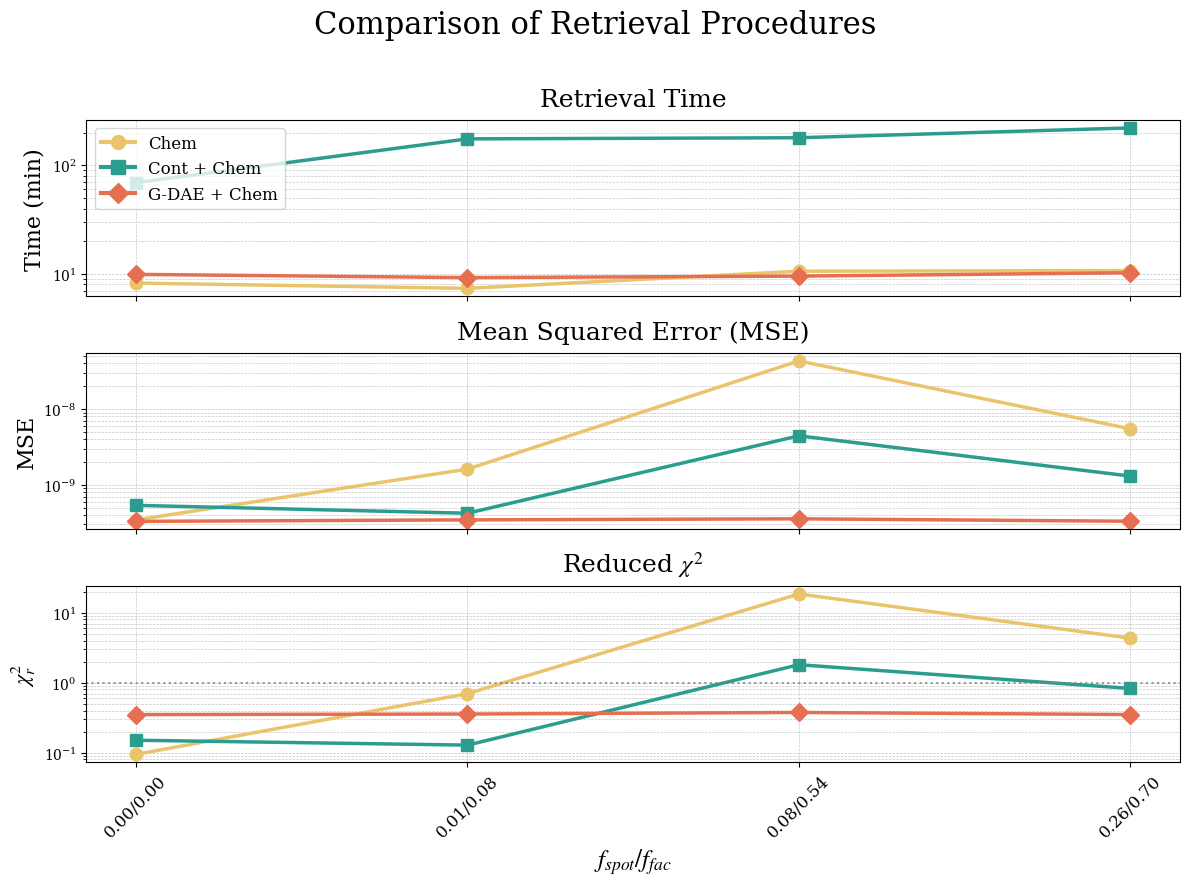

In [75]:
LINE_WIDTH = 2.5
MARKER_SIZE = 9


def make_ratio_label(row: pd.Series) -> str:
    """
    X-axis label in the form: 'spot/facula' with 2 decimals.
    """
    return f"{row['spot_fraction']:.2f}/{row['facula_fraction']:.2f}"


merged_df = merged_df.copy()
merged_df["x_label"] = merged_df.apply(make_ratio_label, axis=1)

x_labels = sorted(
    merged_df["x_label"].unique().tolist(),
    key=lambda s: (float(s.split("/")[0]), float(s.split("/")[1])),
)
x_ticks = np.arange(len(x_labels))

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
fig.suptitle("Comparison of Retrieval Procedures", fontsize=22)

for model_type in MODEL_ORDER:
    model_df = merged_df[merged_df["model_type"] == model_type].copy()
    if model_df.empty:
        continue

    color = PALETTE[model_type]
    marker = MARKERS[model_type]

    sub_10 = model_df[model_df["n_transits"] == 10]
    if sub_10.empty:
        continue

    cols = ["retrieval_time_min", "MSE", "chi2_reduced"]
    df_10t = (
        sub_10.groupby("x_label")[cols]
        .mean()
        .reindex(x_labels)
        .reset_index()
    )

    if df_10t["retrieval_time_min"].isnull().all():
        continue

    axes[0].plot(
        x_ticks,
        df_10t["retrieval_time_min"],
        color=color,
        linestyle="-",
        marker=marker,
        linewidth=LINE_WIDTH,
        markersize=MARKER_SIZE,
    )
    axes[0].set_yscale("log")
    axes[1].plot(
        x_ticks,
        df_10t["MSE"],
        color=color,
        linestyle="-",
        marker=marker,
        linewidth=LINE_WIDTH,
        markersize=MARKER_SIZE,
    )
    axes[2].plot(
        x_ticks,
        df_10t["chi2_reduced"],
        color=color,
        linestyle="-",
        marker=marker,
        linewidth=LINE_WIDTH,
        markersize=MARKER_SIZE,
    )

# Axes formatting
axes[0].set_ylabel("Time (min)", fontsize=16)
axes[0].set_title("Retrieval Time", pad=10, fontsize=18)
axes[0].grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.7)

axes[1].set_ylabel("MSE", fontsize=16)
axes[1].set_title("Mean Squared Error (MSE)", pad=10, fontsize=18)
axes[1].set_yscale("log")
axes[1].grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.7)

axes[2].set_ylabel(r"$\chi^2_r$", fontsize=16)
axes[2].set_title(r"Reduced $\chi^2$", fontsize=18, pad=10)
axes[2].set_yscale("log")
axes[2].grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.7)
axes[2].axhline(1.0, color="gray", lw=1.5, ls=":", alpha=0.8)

axes[2].set_xlabel(r"$f_{spot} / f_{fac}$", fontsize=18)
axes[2].set_xticks(x_ticks)
axes[2].set_xticklabels(x_labels, rotation=45, fontsize=12)

legend_handles = [
    Line2D(
        [0],
        [0],
        color=PALETTE[m],
        lw=3,
        marker=MARKERS[m],
        markersize=10,
        label=LEGEND_LABELS[m],
    )
    for m in MODEL_ORDER
]
axes[0].legend(handles=legend_handles, fontsize=12, loc="upper left")

plt.tight_layout(rect=[0, 0, 1, 0.96])
#plt.savefig("exp0-retrieval_comparison_03-comp.png", dpi=500, bbox_inches="tight")
plt.show()


## 3) Parse POSEIDON `*_results.txt` files

Goal:
- Extract `Model:` metadata (type, transits, spot/facula)
- Extract `log_{gas} = value (+plus)(-minus)` lines from the 1σ constraints block
- Save a tidy CSV with recovered values and min/max 1σ bounds

In [76]:
NUM_RE = r"[-+]?(?:\d+(?:\.\d*)?|\.\d+)(?:[eE][-+]?\d+)?"

MODEL_REGEX = re.compile(
    r"^(?P<model_type>contam|recon|uncontam)_"
    r"(?P<n_transits>\d+)T_"
    r"(?P<spot_fraction>\d+(?:\.\d+)?)spot-"
    r"(?P<facula_fraction>\d+(?:\.\d+)?)fac$"
)

PARAM_LINE_1SIGMA = re.compile(
    rf"^\s*log_(?P<gas>H2O|CH4|CO2|O3)\s*=\s*(?P<val>{NUM_RE})\s*"
    rf"\(\+(?P<plus>{NUM_RE})\)\s*\(\-(?P<minus>{NUM_RE})\)\s*$"
)


def read_text_safely(path: Path) -> str:
    """
    Read text with a few common encodings (handles sigma and other symbols robustly).
    """
    for encoding in ("utf-8", "utf-8-sig", "latin-1"):
        try:
            return path.read_text(encoding=encoding)
        except Exception:
            continue
    return path.read_bytes().decode("latin-1", errors="ignore")


def parse_model_block(text: str) -> Dict[str, object]:
    """
    Extract the 'Model:' line and parse it if it matches the standard pattern.
    """
    model_name = None
    for line in text.splitlines():
        if line.strip().startswith("Model:"):
            model_name = line.split("Model:", 1)[1].strip()
            break

    meta: Dict[str, object] = {"model_name": model_name}
    if model_name:
        match = MODEL_REGEX.match(model_name)
        if match:
            meta.update(
                {
                    "model_type": match.group("model_type"),
                    "n_transits": int(match.group("n_transits")),
                    "spot_fraction": float(match.group("spot_fraction")),
                    "facula_fraction": float(match.group("facula_fraction")),
                }
            )
        else:
            meta.update(
                {
                    "model_type": None,
                    "n_transits": np.nan,
                    "spot_fraction": np.nan,
                    "facula_fraction": np.nan,
                }
            )
    else:
        meta.update(
            {
                "model_type": None,
                "n_transits": np.nan,
                "spot_fraction": np.nan,
                "facula_fraction": np.nan,
            }
        )
    return meta


def find_block_lines_1sigma(text: str) -> List[str]:
    """
    Locate the '1 sigma constraints' block without depending on the literal 'σ'.

    Strategy:
    - find a line starting with '1' and containing 'constraints' (case-insensitive)
    - then advance to the first line containing '='
    - collect subsequent lines until a blank or separator is found
    """
    lines = text.splitlines()
    header_pat = re.compile(r"^\s*1[^\n]*constraints\b", flags=re.IGNORECASE)

    start_idx = None
    for i, line in enumerate(lines):
        if header_pat.search(line):
            start_idx = i
            break
    if start_idx is None:
        return []

    i = start_idx + 1
    while i < len(lines) and "=" not in lines[i]:
        i += 1

    collected: List[str] = []
    while i < len(lines):
        s = lines[i].strip()
        if (not s) or s.startswith(("***", "###", "---", "___")):
            break
        collected.append(s)
        i += 1

    return collected


def parse_params_from_lines(lines: List[str]) -> Dict[str, Dict[str, float]]:
    """
    Parse lines of the form: 'log_CO2 = -2.32 (+0.23)(-0.26)' into value and 1σ min/max.
    """
    out: Dict[str, Dict[str, float]] = {}
    for line in lines:
        match = PARAM_LINE_1SIGMA.match(line)
        if not match:
            continue

        gas = match.group("gas")
        val = float(match.group("val"))
        plus = float(match.group("plus"))
        minus = float(match.group("minus"))

        out[gas] = {"val": val, "min1s": val - minus, "max1s": val + plus}

    return out


def fallback_parse_smallest_uncertainty(text: str) -> Dict[str, Dict[str, float]]:
    """
    Fallback: scan the full file for parameter lines and keep the tightest
    uncertainty per gas (minimizing |plus| + |minus|).
    """
    out: Dict[str, Dict[str, float]] = {}
    best_errsum: Dict[str, float] = {}

    for raw_line in text.splitlines():
        match = PARAM_LINE_1SIGMA.match(raw_line.strip())
        if not match:
            continue

        gas = match.group("gas")
        val = float(match.group("val"))
        plus = float(match.group("plus"))
        minus = float(match.group("minus"))

        errsum = abs(plus) + abs(minus)
        if (gas not in best_errsum) or (errsum < best_errsum[gas]):
            best_errsum[gas] = errsum
            out[gas] = {"val": val, "min1s": val - minus, "max1s": val + plus}

    return out


def parse_poseidon_file(path: Path) -> Dict[str, object]:
    """
    Parse one POSEIDON *_results.txt file into a flat row.
    """
    text = read_text_safely(path)
    meta = parse_model_block(text)

    block_lines = find_block_lines_1sigma(text)
    one_sigma = parse_params_from_lines(block_lines)

    if not one_sigma:
        one_sigma = fallback_parse_smallest_uncertainty(text)

    row: Dict[str, object] = {"file": str(path)}
    row.update(meta)

    for gas in ["CO2", "CH4", "O3", "H2O"]:
        g = one_sigma.get(gas, {})
        row[f"log_{gas}"] = g.get("val", np.nan)
        row[f"log_{gas}_min1s"] = g.get("min1s", np.nan)
        row[f"log_{gas}_max1s"] = g.get("max1s", np.nan)

    return row


def collect_poseidon_results(base_dir: Path) -> pd.DataFrame:
    """
    Recursively parse all '*_results.txt' under base_dir.
    """
    files = sorted(base_dir.rglob("*_results.txt"))
    rows = [parse_poseidon_file(p) for p in files]
    df_out = pd.DataFrame(rows)

    meta_cols = [
        "file",
        "model_name",
        "model_type",
        "n_transits",
        "spot_fraction",
        "facula_fraction",
    ]
    gas_cols: List[str] = []
    for gas in ["CO2", "CH4", "O3", "H2O"]:
        gas_cols.extend([f"log_{gas}", f"log_{gas}_min1s", f"log_{gas}_max1s"])

    ordered = [c for c in meta_cols if c in df_out.columns] + [
        c for c in gas_cols if c in df_out.columns
    ]
    others = [c for c in df_out.columns if c not in ordered]
    df_out = df_out[ordered + others]

    if "n_transits" in df_out.columns:
        df_out["n_transits"] = df_out["n_transits"].astype("Int64")

    for col in ["spot_fraction", "facula_fraction"]:
        if col in df_out.columns:
            df_out[col] = pd.to_numeric(df_out[col], errors="coerce")

    return df_out


In [77]:
poseidon_df = collect_poseidon_results(POSEIDON_BASE_DIR)
poseidon_df.to_csv(POSEIDON_OUT_CSV, index=False)

print(f"Files parsed: {len(poseidon_df)}")
print(f"CSV saved to: {POSEIDON_OUT_CSV}")
print()
print(poseidon_df.head(12).to_string(index=False))

poseidon_df = poseidon_df.dropna()
poseidon_df.head()

Files parsed: 34
CSV saved to: POSEIDON_output\Trappist-1e\retrievals\retrieved_gases_recovered_minmax.csv

                                                                                   file                   model_name model_type  n_transits  spot_fraction  facula_fraction  log_CO2  log_CO2_min1s  log_CO2_max1s  log_CH4  log_CH4_min1s  log_CH4_max1s  log_O3  log_O3_min1s  log_O3_max1s  log_H2O  log_H2O_min1s  log_H2O_max1s
POSEIDON_output\Trappist-1e\retrievals\results\contam_100T_0.00spot-0.00fac_results.txt contam_100T_0.00spot-0.00fac     contam         100           0.00             0.00    -2.57          -2.67          -2.47    -7.22          -7.44          -7.04   -7.61         -7.88         -7.26    -7.20          -7.64          -6.80
POSEIDON_output\Trappist-1e\retrievals\results\contam_100T_0.01spot-0.08fac_results.txt contam_100T_0.01spot-0.08fac     contam         100           0.01             0.08    -2.77          -2.87          -2.67    -7.04          -7.23        

,file,model_name,model_type,n_transits,spot_fraction,facula_fraction,log_CO2,log_CO2_min1s,log_CO2_max1s,log_CH4,log_CH4_min1s,log_CH4_max1s,log_O3,log_O3_min1s,log_O3_max1s,log_H2O,log_H2O_min1s,log_H2O_max1s
0,POSEIDON_output\Trappist-1e\retrievals\results...,contam_100T_0.00spot-0.00fac,contam,100,0.00,0.00,-2.57,-2.67,-2.47,-7.22,-7.44,-7.04,-7.61,-7.88,-7.26,-7.20,-7.64,-6.80
1,POSEIDON_output\Trappist-1e\retrievals\results...,contam_100T_0.01spot-0.08fac,contam,100,0.01,0.08,-2.77,-2.87,-2.67,-7.04,-7.23,-6.88,-7.62,-7.87,-7.26,-7.86,-7.96,-7.69
2,POSEIDON_output\Trappist-1e\retrievals\results...,contam_100T_0.08spot-0.54fac,contam,100,0.08,0.54,-4.06,-4.14,-3.97,-6.27,-6.35,-6.19,-6.96,-7.29,-6.70,-7.97,-7.99,-7.93
3,POSEIDON_output\Trappist-1e\retrievals\results...,contam_100T_0.26spot-0.70fac,contam,100,0.26,0.70,-2.23,-2.30,-2.16,-4.84,-4.89,-4.79,-2.26,-2.34,-2.18,-7.70,-7.91,-7.36
4,POSEIDON_output\Trappist-1e\retrievals\results...,contam_10T_0.00spot-0.00fac,contam,10,0.00,0.00,-2.84,-3.15,-2.52,-7.12,-7.61,-6.72,-7.05,-7.66,-6.43,-6.50,-7.22,-5.98


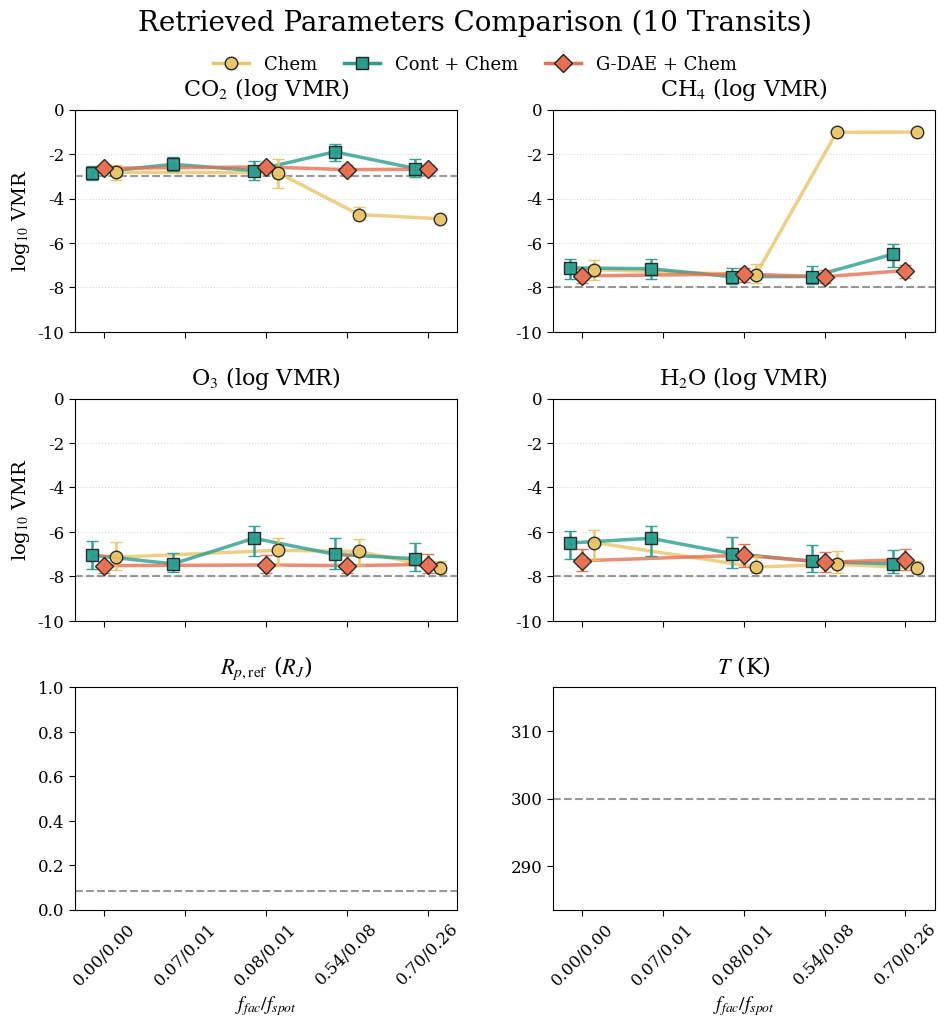

In [78]:
LINE_WIDTH = 2.5
MARKER_SIZE = 9
EDGE_COLOR = "#222222"
ERROR_BAR_WIDTH = 1.8

FAM_OFFSETS = {"contam": -0.15, "recon": 0.0, "uncontam": +0.15}
EXPECTED = {"log_CO2": -3.0, "log_CH4": -8.0, "log_O3": -8.0, "log_H2O": -8.0, "R_p_ref": 0.0821, "T": 300.0}

PARAM_TITLES = {
    "log_CO2": r"CO$_2$ (log VMR)",
    "log_CH4": r"CH$_4$ (log VMR)",
    "log_O3": r"O$_3$ (log VMR)",
    "log_H2O": r"H$_2$O (log VMR)",
    "R_p_ref": r"$R_{p,\mathrm{ref}}$ ($R_J$)",
    "T": r"$T$ (K)"
}
PARAMS_TO_PLOT = ["log_CO2", "log_CH4", "log_O3", "log_H2O", "R_p_ref", "T"]

plot_df = poseidon_df[poseidon_df["n_transits"] == 10].copy()
if plot_df.empty:
    print("Warning: filtered DataFrame is empty (n_transits == 10). Check inputs.")

plot_df["ratio"] = (
    plot_df["facula_fraction"].map(lambda v: f"{v:.2f}")
    + "/"
    + plot_df["spot_fraction"].map(lambda v: f"{v:.2f}")
)

order = sorted(plot_df["ratio"].astype(str).unique())
pos_map = {lab: i for i, lab in enumerate(order)}
plot_df["xpos"] = plot_df["ratio"].map(pos_map)


def plot_param_panel(ax: plt.Axes, param: str, data: pd.DataFrame) -> None:
    """
    Plot recovered values for one parameter with asymmetric 1σ error bars.
    """
    y = param
    y_min = f"{param}_min1s"
    y_max = f"{param}_max1s"

    if param in EXPECTED:
        ax.axhline(
            EXPECTED[param],
            linestyle="--",
            linewidth=1.5,
            color="#555",
            alpha=0.6,
            zorder=1,
            label="True Value"
        )

    if y not in data.columns:
        ax.set_xticks(range(len(order)))
        ax.set_xticklabels(order)
        return

    gdf = data[np.isfinite(data[y])].copy()
    if gdf.empty:
        ax.set_xticks(range(len(order)))
        ax.set_xticklabels(order)
        return

    ax.set_axisbelow(True)
    ax.grid(True, which="major", axis="y", alpha=0.5, linestyle=":", linewidth=0.8)

    for fam in MODEL_ORDER:
        sub = gdf[gdf["model_type"] == fam]
        if sub.empty:
            continue

        color = PALETTE.get(fam, "#555")
        marker = MARKERS.get(fam, "o")

        sub = sub.sort_values("xpos")
        x = sub["xpos"].to_numpy(dtype=float) + FAM_OFFSETS.get(fam, 0.0)
        yv = sub[y].to_numpy(dtype=float)

        if (y_min in sub.columns) and (y_max in sub.columns):
            yerr_low = yv - sub[y_min].to_numpy(dtype=float)
            yerr_up = sub[y_max].to_numpy(dtype=float) - yv
            yerr = np.vstack([yerr_low, yerr_up])
        else:
            yerr = np.zeros((2, len(yv)))

        if len(x) > 1:
            ax.plot(
                x,
                yv,
                linestyle="-",
                linewidth=LINE_WIDTH,
                color=color,
                alpha=0.8,
                zorder=2,
            )

        ax.errorbar(
            x,
            yv,
            yerr=yerr,
            fmt=marker,
            ms=MARKER_SIZE,
            capsize=4,
            capthick=ERROR_BAR_WIDTH * 0.8,
            elinewidth=ERROR_BAR_WIDTH,
            color=color,
            markerfacecolor=color,
            markeredgecolor=EDGE_COLOR,
            markeredgewidth=1.0,
            linestyle="None",
            label=LEGEND_LABELS.get(fam, fam),
            alpha=0.95,
            zorder=3,
        )

    ax.set_xticks(range(len(order)))
    ax.set_xticklabels(order, rotation=0, ha="center")


fig, axes = plt.subplots(3, 2, figsize=(10, 10), sharex="col")
fig.subplots_adjust(
    top=0.88,
    bottom=0.08,
    left=0.10,
    right=0.96,
    wspace=0.25,
    hspace=0.30,
)
fig.suptitle("Retrieved Parameters Comparison (10 Transits)", fontsize=20, y=0.98)

axes_flat = axes.ravel()
for ax, param in zip(axes_flat, PARAMS_TO_PLOT):
    plot_param_panel(ax, param, plot_df)
    ax.set_title(PARAM_TITLES[param], fontsize=16, pad=10)

y_bottom, y_top = -10, 0
y_ticks = np.arange(0, -12, -2)

for i in range(2):
    for j in range(2):
        axes[i, j].set_ylim(y_bottom, y_top)
        axes[i, j].set_yticks(y_ticks)
        axes[i, j].tick_params(labelsize=12, length=4)

        if j == 0:
            axes[i, j].set_ylabel(r"log$_{10}$ VMR", fontsize=14)

# For the third row (R_p_ref and T)
for j in range(2):
    axes[2, j].tick_params(labelsize=12, length=4)
    axes[2, j].set_xlabel(r"$f_{fac}/f_{spot}$", fontsize=14)
    axes[2, j].tick_params(axis="x", rotation=45)

for ax in axes[:, 0]:
    ax.tick_params(axis="y", labelleft=True)
for ax in axes[:, 1]:
    ax.tick_params(axis="y", labelleft=True) # Ensure right column has ticks unhidden
for ax in axes[0:2, :].ravel():
    ax.tick_params(axis="x", labelbottom=False)
for ax in axes[2, :]:
    ax.tick_params(axis="x", labelbottom=True)

present_fams = [m for m in MODEL_ORDER if m in plot_df["model_type"].unique()]
legend_handles = [
    Line2D(
        [0],
        [0],
        marker=MARKERS[f],
        linestyle="-",
        linewidth=LINE_WIDTH,
        color=PALETTE[f],
        markerfacecolor=PALETTE[f],
        markeredgecolor=EDGE_COLOR,
        markeredgewidth=1.0,
        markersize=MARKER_SIZE,
        label=LEGEND_LABELS[f],
    )
    for f in present_fams
]

if legend_handles:
    fig.legend(
        handles=legend_handles,
        loc="lower center",
        bbox_to_anchor=(0.5, 0.90),
        ncols=len(legend_handles),
        frameon=False,
        columnspacing=1.5,
        handlelength=2.0,
        fontsize=13,
    )

#plt.savefig("exp0-retrieval-mixratio-v2-comp.png", dpi=500, bbox_inches="tight")
plt.show()

## 5) PHOENIX + SPHINX comparison with cached DataFrames

This section prepares comparison-ready tables for the two retrieval branches:
- `PHOENIX` = the original retrieval workflow in this folder
- `SPHINX` = the mismatch experiment in `sphinx_injection/`

The clean control `(f_spot, f_fac) = (0.00, 0.00)` is shared between both families, so we explicitly clone the PHOENIX clean rows into the SPHINX tables and mark them with `shared_clean = True`.
All processed tables are cached under `plot_cache/` so the notebook can reload them directly on later runs.


In [79]:
from __future__ import annotations

import re
from pathlib import Path
from typing import Dict, Iterable, List, Tuple

import numpy as np
import pandas as pd


CACHE_DIR = Path("plot_cache")
CACHE_DIR.mkdir(exist_ok=True)

PHOENIX_CHI2_PATH = Path("chi2_log.csv")
PHOENIX_TIMES_PATH = Path("Times")
SPHINX_CHI2_PATH = Path("sphinx_injection/chi2_log_sphinx.csv")
SPHINX_TIMES_PATH = Path("sphinx_injection/Times")

PHOENIX_RESULTS_DIR = Path("POSEIDON_output/Trappist-1e/retrievals/results")
SPHINX_RESULTS_DIR = Path("sphinx_injection/POSEIDON_output/Trappist-1e/retrievals/results")

METRICS_PHOENIX_CACHE = CACHE_DIR / "metrics_phoenix.csv"
METRICS_SPHINX_CACHE = CACHE_DIR / "metrics_sphinx.csv"
METRICS_COMBINED_CACHE = CACHE_DIR / "metrics_combined.csv"
POSEIDON_PHOENIX_CACHE = CACHE_DIR / "poseidon_phoenix.csv"
POSEIDON_SPHINX_CACHE = CACHE_DIR / "poseidon_sphinx.csv"
POSEIDON_COMBINED_CACHE = CACHE_DIR / "poseidon_combined.csv"

REBUILD_COMPARISON_CACHE = False
PLOT_N_TRANSITS = 10
TARGET_CASES = [(0.00, 0.00), (0.01, 0.08), (0.08, 0.54), (0.26, 0.70)]
TARGET_CASE_SET = {(round(s, 2), round(f, 2)) for s, f in TARGET_CASES}

SOURCE_ORDER = ["phoenix", "sphinx"]
SOURCE_LABELS = {"phoenix": "PHOENIX", "sphinx": "SPHINX"}
SOURCE_LINESTYLES = {"phoenix": "-", "sphinx": "--"}
SOURCE_MARKER_FACE = {"phoenix": "filled", "sphinx": "open"}

# Keep the procedure color coding from the original notebook.
COMPARE_PALETTE = {
    "uncontam": "#E9C46A",
    "contam": "#2A9D8F",
    "recon": "#E76F51",
}
COMPARE_MARKERS = {"uncontam": "o", "contam": "s", "recon": "D"}
COMPARE_LABELS = {"uncontam": "Chem", "contam": "Cont + Chem", "recon": "G-DAE + Chem"}
COMPARE_MODEL_ORDER = ["uncontam", "contam", "recon"]

NUM_RE = r"[-+]?(?:\d+(?:\.\d*)?|\.\d+)(?:[eE][-+]?\d+)?"
MODEL_NAME_RE = re.compile(
    r"^(?P<prefix>sphinx_)?"
    r"(?P<model_type>contam|recon|uncontam)_"
    r"(?P<n_transits>\d+)T_"
    r"(?P<spot_fraction>\d+(?:\.\d+)?)spot-"
    r"(?P<facula_fraction>\d+(?:\.\d+)?)fac$"
)
PARAM_LINE_1SIGMA = re.compile(
    rf"^\s*(?P<param>R_p_ref|T|log_H2O|log_CH4|log_CO2|log_O3)\s*=\s*(?P<val>{NUM_RE})\s*"
    rf"\(\+(?P<plus>{NUM_RE})\)\s*\(\-(?P<minus>{NUM_RE})\)(?:\s+.*)?$"
)


def parse_standard_model_name(model_name: str) -> Dict[str, object]:
    """Parse model metadata from names like `recon_10T_0.08spot-0.54fac` or `sphinx_recon_10T_...`."""
    match = MODEL_NAME_RE.match(str(model_name))
    if not match:
        return {
            "model_type": None,
            "n_transits": pd.NA,
            "spot_fraction": np.nan,
            "facula_fraction": np.nan,
            "parsed_source_family": None,
        }

    return {
        "model_type": match.group("model_type"),
        "n_transits": int(match.group("n_transits")),
        "spot_fraction": float(match.group("spot_fraction")),
        "facula_fraction": float(match.group("facula_fraction")),
        "parsed_source_family": "sphinx" if match.group("prefix") else "phoenix",
    }


def parse_ffacfspot(ffacfspot: str) -> Tuple[float, float]:
    facula_fraction, spot_fraction = str(ffacfspot).split("-")
    return float(facula_fraction), float(spot_fraction)


def normalize_times_table(times_path: Path, source_family: str) -> pd.DataFrame:
    times_df = pd.read_csv(times_path, sep=r"\s+", engine="python")
    times_df["Mode"] = times_df["Mode"].astype(str).str.replace('"', '', regex=False)
    times_df[["facula_fraction", "spot_fraction"]] = (
        times_df["ffacfspot"].astype(str).apply(lambda x: pd.Series(parse_ffacfspot(x)))
    )
    times_df = times_df.rename(
        columns={"N_T": "n_transits", "Mode": "model_type", "Time": "retrieval_time_min"}
    ).drop(columns=["ffacfspot"])
    times_df["source_family"] = source_family
    times_df["shared_clean"] = False
    return times_df


def filter_target_cases(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        return df.copy()
    out = df.copy()
    out["spot_fraction"] = pd.to_numeric(out["spot_fraction"], errors="coerce")
    out["facula_fraction"] = pd.to_numeric(out["facula_fraction"], errors="coerce")
    key = list(zip(out["spot_fraction"].round(2), out["facula_fraction"].round(2)))
    mask = [(s, f) in TARGET_CASE_SET for s, f in key]
    out = out[np.asarray(mask, dtype=bool)].copy()
    return out


def load_metrics_table(chi2_path: Path, times_path: Path, source_family: str) -> pd.DataFrame:
    chi2_df = pd.read_csv(chi2_path).copy()
    parsed = chi2_df["model_name"].apply(lambda x: pd.Series(parse_standard_model_name(str(x))))
    chi2_df = pd.concat([chi2_df, parsed], axis=1)
    chi2_df = chi2_df[chi2_df["model_type"].notna()].copy()
    chi2_df["source_family"] = source_family
    chi2_df["shared_clean"] = False

    times_df = normalize_times_table(times_path, source_family=source_family)

    merged = pd.merge(
        chi2_df,
        times_df,
        on=["n_transits", "model_type", "spot_fraction", "facula_fraction", "source_family", "shared_clean"],
        how="left",
    )

    merged = filter_target_cases(merged)
    if "n_transits" in merged.columns:
        merged["n_transits"] = pd.to_numeric(merged["n_transits"], errors="coerce").astype("Int64")
    return merged


def read_text_safely(path: Path) -> str:
    for encoding in ("utf-8", "utf-8-sig", "latin-1"):
        try:
            return path.read_text(encoding=encoding)
        except Exception:
            continue
    return path.read_bytes().decode("latin-1", errors="ignore")


def parse_model_metadata_from_text(text: str, source_family: str) -> Dict[str, object]:
    model_name = None
    for line in text.splitlines():
        if line.strip().startswith("Model:"):
            model_name = line.split("Model:", 1)[1].strip()
            break

    meta = {"model_name": model_name}
    meta.update(parse_standard_model_name(model_name or ""))
    if meta.get("parsed_source_family") is None:
        meta["parsed_source_family"] = source_family
    return meta


def find_block_lines_1sigma(text: str) -> List[str]:
    lines = text.splitlines()
    header_pat = re.compile(r"^\s*1[^\n]*constraints\b", flags=re.IGNORECASE)

    start_idx = None
    for i, line in enumerate(lines):
        if header_pat.search(line):
            start_idx = i
            break
    if start_idx is None:
        return []

    i = start_idx + 1
    while i < len(lines) and "=" not in lines[i]:
        i += 1

    collected: List[str] = []
    while i < len(lines):
        s = lines[i].strip()
        if (not s) or s.startswith(("***", "###", "---", "___")):
            break
        collected.append(s)
        i += 1
    return collected


def parse_params_from_lines(lines: Iterable[str]) -> Dict[str, Dict[str, float]]:
    out: Dict[str, Dict[str, float]] = {}
    for line in lines:
        match = PARAM_LINE_1SIGMA.match(str(line).strip())
        if not match:
            continue

        param = match.group("param")
        val = float(match.group("val"))
        plus = float(match.group("plus"))
        minus = float(match.group("minus"))
        out[param] = {"val": val, "min1s": val - minus, "max1s": val + plus}
    return out


def fallback_parse_smallest_uncertainty(text: str) -> Dict[str, Dict[str, float]]:
    out: Dict[str, Dict[str, float]] = {}
    best_errsum: Dict[str, float] = {}
    for raw_line in text.splitlines():
        match = PARAM_LINE_1SIGMA.match(raw_line.strip())
        if not match:
            continue
        param = match.group("param")
        val = float(match.group("val"))
        plus = float(match.group("plus"))
        minus = float(match.group("minus"))
        errsum = abs(plus) + abs(minus)
        if (param not in best_errsum) or (errsum < best_errsum[param]):
            best_errsum[param] = errsum
            out[param] = {"val": val, "min1s": val - minus, "max1s": val + plus}
    return out


def parse_poseidon_results_file(path: Path, source_family: str) -> Dict[str, object]:
    text = read_text_safely(path)
    meta = parse_model_metadata_from_text(text, source_family=source_family)
    row: Dict[str, object] = {"file": str(path)}
    row.update(meta)
    row["source_family"] = source_family
    row["shared_clean"] = False

    if row.get("model_type") is None:
        return row

    block_lines = find_block_lines_1sigma(text)
    one_sigma = parse_params_from_lines(block_lines)
    if not one_sigma:
        one_sigma = fallback_parse_smallest_uncertainty(text)

    params_to_store = ["log_CO2", "log_CH4", "log_O3", "log_H2O", "R_p_ref", "T"]
    for param in params_to_store:
        parsed = one_sigma.get(param, {})
        row[param] = parsed.get("val", np.nan)
        row[f"{param}_min1s"] = parsed.get("min1s", np.nan)
        row[f"{param}_max1s"] = parsed.get("max1s", np.nan)

    return row


def collect_poseidon_results_table(results_dir: Path, source_family: str) -> pd.DataFrame:
    files = sorted(results_dir.rglob("*_results.txt"))
    rows = [parse_poseidon_results_file(path, source_family=source_family) for path in files]
    df_out = pd.DataFrame(rows)
    if df_out.empty:
        return df_out

    df_out = df_out[df_out["model_type"].notna()].copy()
    df_out = filter_target_cases(df_out)
    df_out["n_transits"] = pd.to_numeric(df_out["n_transits"], errors="coerce").astype("Int64")

    preferred = [
        "file", "model_name", "source_family", "shared_clean", "model_type", "n_transits", "spot_fraction", "facula_fraction",
        "log_CO2", "log_CO2_min1s", "log_CO2_max1s",
        "log_CH4", "log_CH4_min1s", "log_CH4_max1s",
        "log_O3", "log_O3_min1s", "log_O3_max1s",
        "log_H2O", "log_H2O_min1s", "log_H2O_max1s",
        "R_p_ref", "R_p_ref_min1s", "R_p_ref_max1s",
        "T", "T_min1s", "T_max1s",
    ]
    existing = [c for c in preferred if c in df_out.columns]
    others = [c for c in df_out.columns if c not in existing]
    return df_out[existing + others]


def clone_clean_controls(base_df: pd.DataFrame, target_source_family: str) -> pd.DataFrame:
    clean = base_df[
        (base_df["spot_fraction"].round(2) == 0.0)
        & (base_df["facula_fraction"].round(2) == 0.0)
    ].copy()
    if clean.empty:
        return clean
    clean["source_family"] = target_source_family
    clean["shared_clean"] = True
    return clean


def build_comparison_tables() -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    metrics_phoenix = load_metrics_table(PHOENIX_CHI2_PATH, PHOENIX_TIMES_PATH, source_family="phoenix")
    metrics_sphinx = load_metrics_table(SPHINX_CHI2_PATH, SPHINX_TIMES_PATH, source_family="sphinx")
    metrics_sphinx = pd.concat([metrics_sphinx, clone_clean_controls(metrics_phoenix, "sphinx")], ignore_index=True)

    poseidon_phoenix = collect_poseidon_results_table(PHOENIX_RESULTS_DIR, source_family="phoenix")
    poseidon_sphinx = collect_poseidon_results_table(SPHINX_RESULTS_DIR, source_family="sphinx")
    poseidon_sphinx = pd.concat([poseidon_sphinx, clone_clean_controls(poseidon_phoenix, "sphinx")], ignore_index=True)

    metrics_combined = pd.concat([metrics_phoenix, metrics_sphinx], ignore_index=True)
    poseidon_combined = pd.concat([poseidon_phoenix, poseidon_sphinx], ignore_index=True)

    metrics_phoenix.to_csv(METRICS_PHOENIX_CACHE, index=False)
    metrics_sphinx.to_csv(METRICS_SPHINX_CACHE, index=False)
    metrics_combined.to_csv(METRICS_COMBINED_CACHE, index=False)
    poseidon_phoenix.to_csv(POSEIDON_PHOENIX_CACHE, index=False)
    poseidon_sphinx.to_csv(POSEIDON_SPHINX_CACHE, index=False)
    poseidon_combined.to_csv(POSEIDON_COMBINED_CACHE, index=False)

    return (
        metrics_phoenix, metrics_sphinx, metrics_combined,
        poseidon_phoenix, poseidon_sphinx, poseidon_combined,
    )


def load_cached_comparison_tables() -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    return (
        pd.read_csv(METRICS_PHOENIX_CACHE),
        pd.read_csv(METRICS_SPHINX_CACHE),
        pd.read_csv(METRICS_COMBINED_CACHE),
        pd.read_csv(POSEIDON_PHOENIX_CACHE),
        pd.read_csv(POSEIDON_SPHINX_CACHE),
        pd.read_csv(POSEIDON_COMBINED_CACHE),
    )


In [80]:
CACHE_PATHS = [
    METRICS_PHOENIX_CACHE,
    METRICS_SPHINX_CACHE,
    METRICS_COMBINED_CACHE,
    POSEIDON_PHOENIX_CACHE,
    POSEIDON_SPHINX_CACHE,
    POSEIDON_COMBINED_CACHE,
]

if REBUILD_COMPARISON_CACHE or any(not path.exists() for path in CACHE_PATHS):
    (
        metrics_phoenix_df,
        metrics_sphinx_df,
        metrics_combined_df,
        poseidon_phoenix_df,
        poseidon_sphinx_df,
        poseidon_combined_df,
    ) = build_comparison_tables()
    print("Rebuilt comparison caches under:", CACHE_DIR.resolve())
else:
    (
        metrics_phoenix_df,
        metrics_sphinx_df,
        metrics_combined_df,
        poseidon_phoenix_df,
        poseidon_sphinx_df,
        poseidon_combined_df,
    ) = load_cached_comparison_tables()
    print("Loaded cached comparison tables from:", CACHE_DIR.resolve())

print()
print("metrics_combined_df columns:")
print(metrics_combined_df.columns.tolist())
print()
print(metrics_combined_df.head())
print()
print("poseidon_combined_df columns:")
print(poseidon_combined_df.columns.tolist())
print()
print(poseidon_combined_df.head())


Loaded cached comparison tables from: C:\Proyectos\Astro\gdaespec\Earth_like_Atmosphere\Retrieval Tests\plot_cache

metrics_combined_df columns:
['planet_name', 'model_name', 'dof', 'chi2', 'chi2_reduced', 'N', 'p', 'MSE', 'observation', 'model_type', 'n_transits', 'spot_fraction', 'facula_fraction', 'parsed_source_family', 'source_family', 'shared_clean', 'retrieval_time_min', 'retrieval_strategy', 'metrics_basis', 'rmse', 'rmse_ppm']

   planet_name                   model_name  dof         chi2  chi2_reduced  \
0  Trappist-1e   recon_10T_0.08spot-0.54fac  374   140.481671      0.375619   
1  Trappist-1e   recon_10T_0.26spot-0.70fac  374   131.115889      0.350577   
2  Trappist-1e   recon_10T_0.01spot-0.08fac  374   133.372519      0.356611   
3  Trappist-1e   recon_10T_0.00spot-0.00fac  374   130.982987      0.350222   
4  Trappist-1e  recon_100T_0.00spot-0.00fac  374  1267.056967      3.387853   

     N   p           MSE observation model_type  ...  spot_fraction  \
0  385  11  3

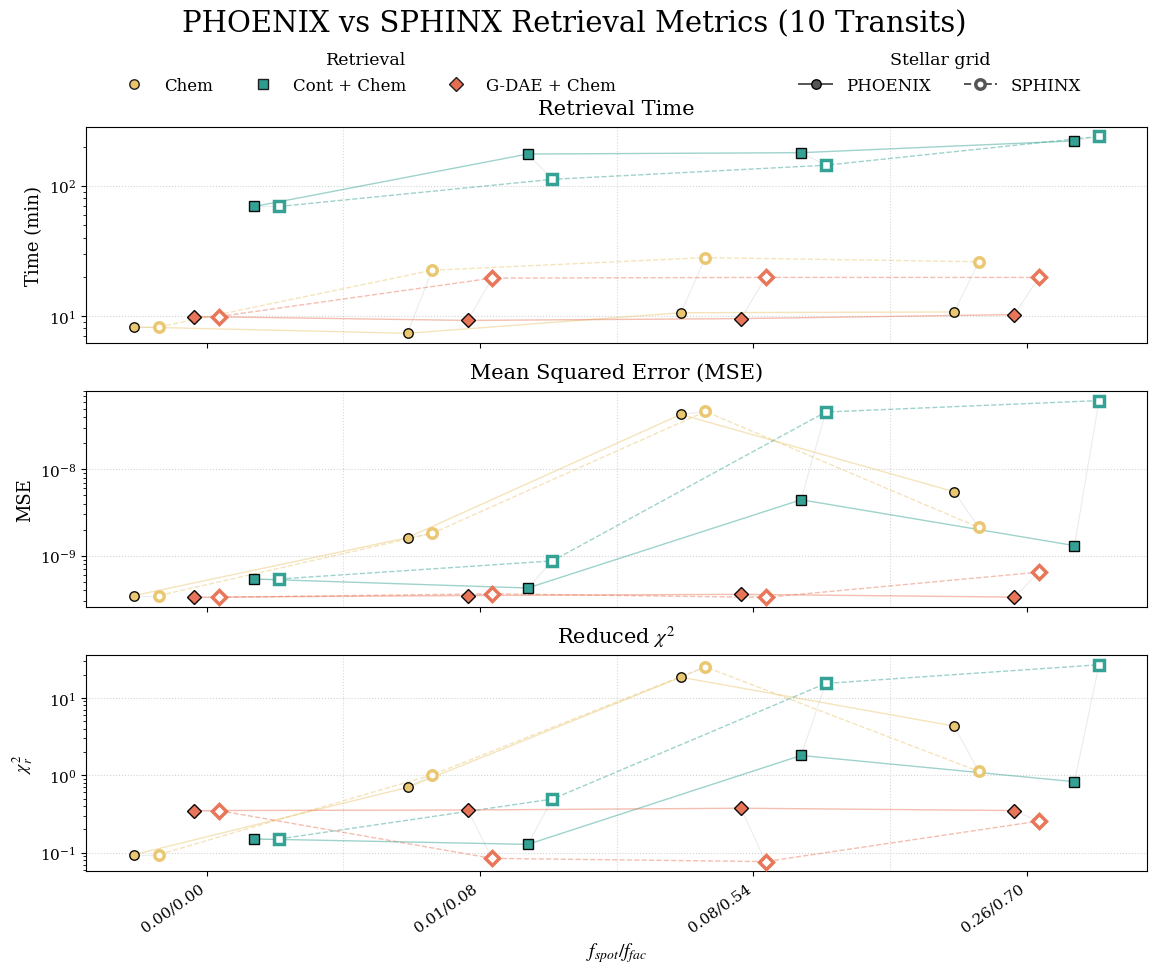

In [93]:
LINE_WIDTH = 1.8
MARKER_SIZE = 6.8
PAIR_LINEWIDTH = 0.8
PAIR_ALPHA = 0.16
EDGE_COLOR = "#1f1f1f"
BASE_OFFSETS = {"uncontam": -0.22, "recon": 0.0, "contam": 0.22}
SOURCE_OFFSETS = {"phoenix": -0.045, "sphinx": 0.045}

metrics_plot_df = metrics_combined_df.copy()
metrics_plot_df["n_transits"] = pd.to_numeric(metrics_plot_df["n_transits"], errors="coerce")
metrics_plot_df = metrics_plot_df[metrics_plot_df["n_transits"] == PLOT_N_TRANSITS].copy()
metrics_plot_df["spot_fraction"] = pd.to_numeric(metrics_plot_df["spot_fraction"], errors="coerce")
metrics_plot_df["facula_fraction"] = pd.to_numeric(metrics_plot_df["facula_fraction"], errors="coerce")
metrics_plot_df["case_key"] = metrics_plot_df.apply(
    lambda row: (round(float(row["spot_fraction"]), 2), round(float(row["facula_fraction"]), 2)),
    axis=1,
)
metrics_plot_df = metrics_plot_df[metrics_plot_df["case_key"].isin(TARGET_CASE_SET)].copy()
metrics_plot_df["x_label"] = metrics_plot_df.apply(
    lambda row: f"{float(row['spot_fraction']):.2f}/{float(row['facula_fraction']):.2f}",
    axis=1,
)
metrics_plot_df["is_shared_clean"] = metrics_plot_df.apply(
    lambda row: bool(row.get("shared_clean", False)) and row["case_key"] == (0.0, 0.0),
    axis=1,
)

x_labels = [f"{spot:.2f}/{fac:.2f}" for spot, fac in TARGET_CASES]
x_center_map = {case: i for i, case in enumerate(TARGET_CASES)}
metrics_plot_df["x_center"] = metrics_plot_df["case_key"].map(x_center_map)

def compute_xpos(row: pd.Series) -> float:
    base = BASE_OFFSETS[row["model_type"]]
    return float(row["x_center"] + base + SOURCE_OFFSETS[row["source_family"]])

metrics_plot_df["xpos"] = metrics_plot_df.apply(compute_xpos, axis=1)
metrics_display_df = metrics_plot_df.copy()

metric_specs = [
    ("retrieval_time_min", "Time (min)", "Retrieval Time", True),
    ("MSE", "MSE", "Mean Squared Error (MSE)", True),
    ("chi2_reduced", r"$\chi^2_r$", r"Reduced $\chi^2$", True),
]

fig, axes = plt.subplots(3, 1, figsize=(12.2, 9.8), sharex=True)
fig.subplots_adjust(top=0.86, bottom=0.10, left=0.10, right=0.97, hspace=0.22)
fig.suptitle(f"PHOENIX vs SPHINX Retrieval Metrics ({PLOT_N_TRANSITS} Transits)", fontsize=21, y=0.98)

for ax, (_metric, _ylabel, _title, _logscale) in zip(axes, metric_specs):
    for boundary in range(len(TARGET_CASES) - 1):
        ax.axvline(boundary + 0.5, color="#d8d8d8", lw=0.8, ls=":", zorder=0)
    ax.grid(True, which="major", axis="y", linestyle=":", linewidth=0.8, alpha=0.55)
    ax.set_axisbelow(True)

for ax, (metric, ylabel, title, use_log) in zip(axes, metric_specs):
    pair_df = metrics_plot_df.copy()
    for model_type in COMPARE_MODEL_ORDER:
        sub_pair = pair_df[pair_df["model_type"] == model_type].copy()
        if sub_pair.empty:
            continue
        for _, grp in sub_pair.groupby("case_key"):
            grp = grp.sort_values("source_family")
            if grp.shape[0] < 2:
                continue
            vals = pd.to_numeric(grp[metric], errors="coerce")
            if not np.isfinite(vals).all():
                continue
            ax.plot(
                grp["xpos"].to_numpy(dtype=float),
                vals.to_numpy(dtype=float),
                color="#8a8a8a",
                lw=PAIR_LINEWIDTH,
                alpha=PAIR_ALPHA,
                zorder=1,
            )

    for model_type in COMPARE_MODEL_ORDER:
        for source_family in SOURCE_ORDER:
            sub = metrics_display_df[
                (metrics_display_df["model_type"] == model_type)
                & (metrics_display_df["source_family"] == source_family)
            ].copy()
            if sub.empty:
                continue
            sub = sub.sort_values(["x_center", "xpos"])
            yv = pd.to_numeric(sub[metric], errors="coerce").to_numpy(dtype=float)
            mask = np.isfinite(yv)
            if not mask.any():
                continue
            sub = sub.loc[mask]
            yv = yv[mask]
            color = COMPARE_PALETTE[model_type]
            marker = COMPARE_MARKERS[model_type]
            markerface = color if source_family == "phoenix" else "white"
            markeredge = "black" if source_family == "phoenix" else color
            mew = 1.0 if source_family == "phoenix" else 2.5
            ax.plot(
                sub["xpos"],
                yv,
                linestyle=SOURCE_LINESTYLES[source_family],
                linewidth=1.0,
                color=color,
                alpha=0.45,
                zorder=2,
            )
            ax.plot(
                sub["xpos"],
                yv,
                linestyle="None",
                marker=marker,
                markersize=MARKER_SIZE,
                color=color,
                markerfacecolor=markerface,
                markeredgecolor=markeredge,
                markeredgewidth=mew,
                alpha=0.95,
                zorder=3.2,
            )

    ax.set_title(title, fontsize=15, pad=9)
    ax.set_ylabel(ylabel, fontsize=13)
    if use_log:
        ax.set_yscale("log")
    ax.tick_params(labelsize=11)

axes[-1].set_xticks(range(len(x_labels)))
axes[-1].set_xticklabels(x_labels, rotation=35, ha="right")
axes[-1].set_xlabel(r"$f_{spot}/f_{fac}$", fontsize=14)

procedure_handles = [
    Line2D(
        [0], [0], marker=COMPARE_MARKERS[m], linestyle="None", color=COMPARE_PALETTE[m],
        markerfacecolor=COMPARE_PALETTE[m], markeredgecolor=EDGE_COLOR,
        markeredgewidth=1.0, markersize=MARKER_SIZE, label=COMPARE_LABELS[m],
    )
    for m in COMPARE_MODEL_ORDER
]
family_handles = [
    Line2D(
        [0], [0], marker="o", linestyle=SOURCE_LINESTYLES[src], linewidth=1.4, color="#555555",
        markerfacecolor="#555555" if src == "phoenix" else "white",
        markeredgecolor="black" if src == "phoenix" else "#555555",
        markeredgewidth=1.0 if src == "phoenix" else 2.5,
        markersize=MARKER_SIZE, label=SOURCE_LABELS[src],
    )
    for src in SOURCE_ORDER
]

fig.legend(
    handles=procedure_handles, loc="upper center", bbox_to_anchor=(0.33, 0.952),
    ncols=3, frameon=False, fontsize=12, title="Retrieval", title_fontsize=12.5
)
fig.legend(
    handles=family_handles, loc="upper center", bbox_to_anchor=(0.80, 0.952),
    ncols=2, frameon=False, fontsize=12, title="Stellar grid", title_fontsize=12.5
)
plt.savefig("exp0_retrieval_comparison_metrics.png", dpi=500, bbox_inches="tight")
plt.savefig("exp0_retrieval_comparison_metrics.pdf", dpi=500, bbox_inches="tight")
plt.show()






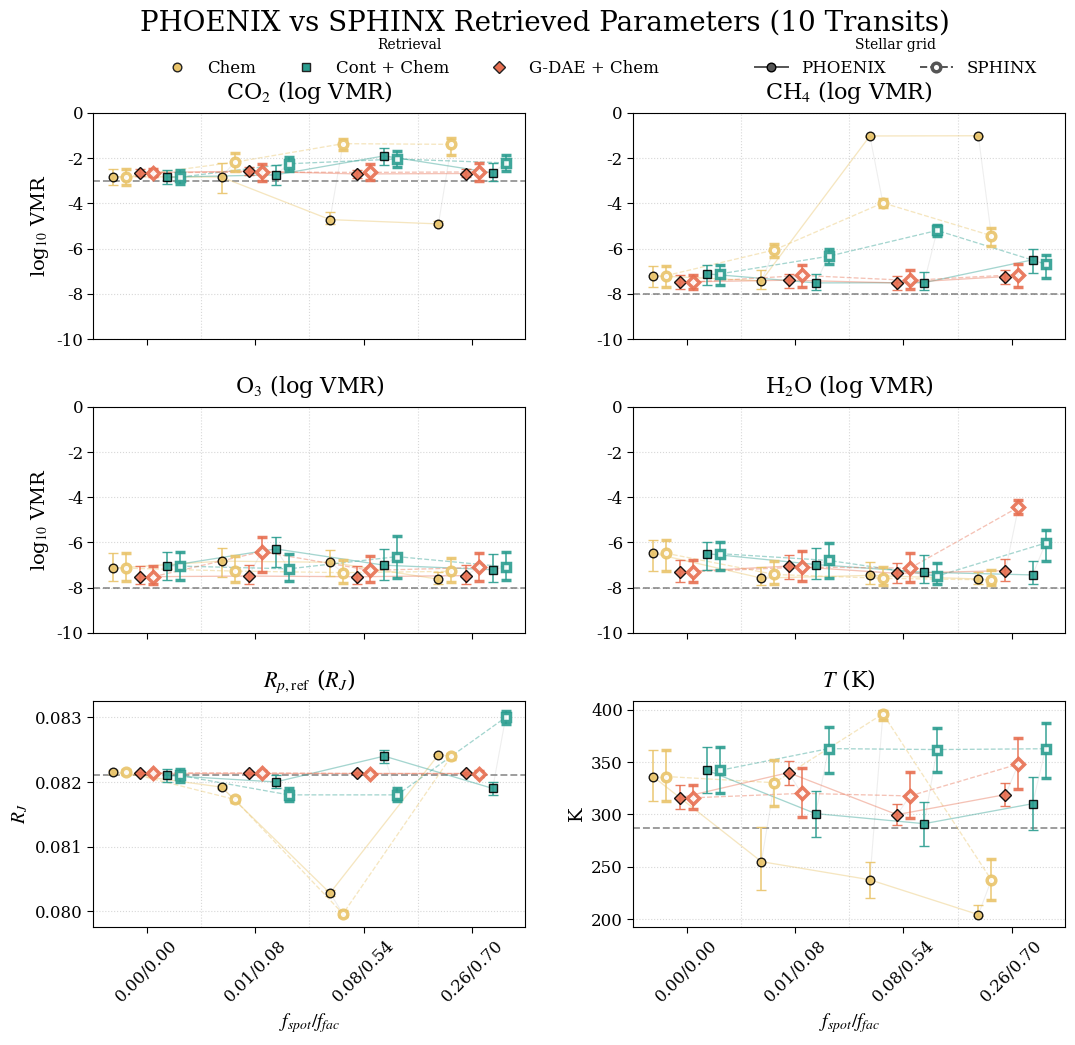

In [98]:
MARKER_SIZE = 6.2
EDGE_COLOR = "#222222"
ERROR_BAR_WIDTH = 1.15
PAIR_LINEWIDTH = 0.8
PAIR_ALPHA = 0.14
BASE_OFFSETS = {"uncontam": -0.25, "recon": 0.0, "contam": 0.25}
SOURCE_OFFSETS = {"phoenix": -0.06, "sphinx": 0.06}

EXPECTED = {
    "log_CO2": -3.0,
    "log_CH4": -8.0,
    "log_O3": -8.0,
    "log_H2O": -8.0,
    "R_p_ref": 0.0821,
    "T": 287.0,
}
PARAM_TITLES = {
    "log_CO2": r"CO$_2$ (log VMR)",
    "log_CH4": r"CH$_4$ (log VMR)",
    "log_O3": r"O$_3$ (log VMR)",
    "log_H2O": r"H$_2$O (log VMR)",
    "R_p_ref": r"$R_{p,\mathrm{ref}}$ ($R_J$)",
    "T": r"$T$ (K)",
}
PARAMS_TO_PLOT = ["log_CO2", "log_CH4", "log_O3", "log_H2O", "R_p_ref", "T"]

plot_df = poseidon_combined_df.copy()
plot_df["n_transits"] = pd.to_numeric(plot_df["n_transits"], errors="coerce")
plot_df = plot_df[plot_df["n_transits"] == PLOT_N_TRANSITS].copy()
plot_df["spot_fraction"] = pd.to_numeric(plot_df["spot_fraction"], errors="coerce")
plot_df["facula_fraction"] = pd.to_numeric(plot_df["facula_fraction"], errors="coerce")
plot_df["case_key"] = plot_df.apply(
    lambda row: (round(float(row["spot_fraction"]), 2), round(float(row["facula_fraction"]), 2)),
    axis=1,
)
plot_df = plot_df[plot_df["case_key"].isin(TARGET_CASE_SET)].copy()
plot_df["ratio"] = plot_df.apply(
    lambda row: f"{float(row['spot_fraction']):.2f}/{float(row['facula_fraction']):.2f}",
    axis=1,
)
plot_df["is_shared_clean"] = plot_df.apply(
    lambda row: bool(row.get("shared_clean", False)) and row["case_key"] == (0.0, 0.0),
    axis=1,
)
order = [f"{spot:.2f}/{fac:.2f}" for spot, fac in TARGET_CASES]
pos_map = {label: i for i, label in enumerate(order)}
plot_df["x_center"] = plot_df["ratio"].map(pos_map)

def compute_param_xpos(row: pd.Series) -> float:
    base = BASE_OFFSETS[row["model_type"]]
    return float(row["x_center"] + base + SOURCE_OFFSETS[row["source_family"]])

plot_df["xpos"] = plot_df.apply(compute_param_xpos, axis=1)
plot_df = plot_df.dropna(subset=["x_center", "xpos"])
plot_display_df = plot_df.copy()


def plot_param_panel(ax: plt.Axes, param: str, data: pd.DataFrame, display_data: pd.DataFrame) -> None:
    y_min = f"{param}_min1s"
    y_max = f"{param}_max1s"

    for boundary in range(len(order) - 1):
        ax.axvline(boundary + 0.5, color="#d8d8d8", lw=0.8, ls=":", zorder=0)
    if param in EXPECTED:
        ax.axhline(EXPECTED[param], linestyle="--", linewidth=1.35, color="#555", alpha=0.6, zorder=1)

    if param not in data.columns:
        ax.set_xticks(range(len(order)))
        ax.set_xticklabels(order)
        return

    gdf = data[np.isfinite(pd.to_numeric(data[param], errors="coerce"))].copy()
    disp = display_data[np.isfinite(pd.to_numeric(display_data[param], errors="coerce"))].copy()
    if gdf.empty or disp.empty:
        ax.set_xticks(range(len(order)))
        ax.set_xticklabels(order)
        return

    ax.set_axisbelow(True)
    ax.grid(True, which="major", axis="y", alpha=0.5, linestyle=":", linewidth=0.8)

    for model_type in COMPARE_MODEL_ORDER:
        pair_df = gdf[(gdf["model_type"] == model_type)].copy()
        if pair_df.empty:
            continue
        for _, grp in pair_df.groupby("case_key"):
            grp = grp.sort_values("source_family")
            if grp.shape[0] < 2:
                continue
            x_vals = grp["xpos"].to_numpy(dtype=float)
            y_vals = pd.to_numeric(grp[param], errors="coerce").to_numpy(dtype=float)
            if not np.isfinite(y_vals).all() or np.ptp(x_vals) < 1e-10:
                continue
            ax.plot(
                x_vals,
                y_vals,
                color="#8a8a8a",
                lw=PAIR_LINEWIDTH,
                alpha=PAIR_ALPHA,
                zorder=1.5,
            )

    for model_type in COMPARE_MODEL_ORDER:
        for source_family in SOURCE_ORDER:
            sub = disp[(disp["model_type"] == model_type) & (disp["source_family"] == source_family)].copy()
            if sub.empty:
                continue

            sub = sub.sort_values(["x_center", "xpos"])
            x = sub["xpos"].to_numpy(dtype=float)
            yv = pd.to_numeric(sub[param], errors="coerce").to_numpy(dtype=float)

            if (y_min in sub.columns) and (y_max in sub.columns):
                y_low = pd.to_numeric(sub[y_min], errors="coerce").to_numpy(dtype=float)
                y_high = pd.to_numeric(sub[y_max], errors="coerce").to_numpy(dtype=float)
                yerr_low = yv - y_low
                yerr_up = y_high - yv
                yerr = np.vstack([yerr_low, yerr_up])
            else:
                yerr = np.zeros((2, len(yv)))

            color = COMPARE_PALETTE[model_type]
            marker = COMPARE_MARKERS[model_type]
            markerface = color if source_family == "phoenix" else "white"
            markeredge = "black" if source_family == "phoenix" else color
            mew = 1.0 if source_family == "phoenix" else 2.5
            ax.plot(
                x,
                yv,
                linestyle=SOURCE_LINESTYLES[source_family],
                linewidth=0.95,
                color=color,
                alpha=0.42,
                zorder=2,
            )

            ax.errorbar(
                x,
                yv,
                yerr=yerr,
                fmt=marker,
                ms=MARKER_SIZE,
                capsize=3.5,
                capthick=ERROR_BAR_WIDTH * 0.8,
                elinewidth=ERROR_BAR_WIDTH,
                color=color,
                markerfacecolor=markerface,
                markeredgecolor=markeredge,
                markeredgewidth=mew,
                linestyle="None",
                alpha=0.90,
                zorder=3,
            )

    ax.set_xticks(range(len(order)))
    ax.set_xticklabels(order, rotation=0, ha="center")


fig, axes = plt.subplots(3, 2, figsize=(11.3, 10.3), sharex="col")
fig.subplots_adjust(top=0.88, bottom=0.09, left=0.10, right=0.96, wspace=0.25, hspace=0.30)
fig.suptitle(f"PHOENIX vs SPHINX Retrieved Parameters ({PLOT_N_TRANSITS} Transits)", fontsize=20, y=0.98)

axes_flat = axes.ravel()
for ax, param in zip(axes_flat, PARAMS_TO_PLOT):
    plot_param_panel(ax, param, plot_df, plot_display_df)
    ax.set_title(PARAM_TITLES[param], fontsize=16, pad=10)

# Composition rows
y_bottom, y_top = -10, 0
y_ticks = np.arange(0, -12, -2)
for i in range(2):
    for j in range(2):
        axes[i, j].set_ylim(y_bottom, y_top)
        axes[i, j].set_yticks(y_ticks)
        axes[i, j].tick_params(labelsize=12, length=4)
        if j == 0:
            axes[i, j].set_ylabel(r"log$_{10}$ VMR", fontsize=14)

for j in range(2):
    axes[2, j].tick_params(labelsize=12, length=4)
    axes[2, j].set_xlabel(r"$f_{spot}/f_{fac}$", fontsize=14)
    axes[2, j].tick_params(axis="x", rotation=45)

axes[2, 0].set_ylabel(r"$R_J$", fontsize=14)
axes[2, 1].set_ylabel("K", fontsize=14)

for ax in axes[0:2, :].ravel():
    ax.tick_params(axis="x", labelbottom=False)
for ax in axes[2, :]:
    ax.tick_params(axis="x", labelbottom=True)


procedure_handles = [
    Line2D(
        [0], [0], marker=COMPARE_MARKERS[m], linestyle="None", color=COMPARE_PALETTE[m],
        markerfacecolor=COMPARE_PALETTE[m], markeredgecolor=EDGE_COLOR,
        markeredgewidth=1.0, markersize=MARKER_SIZE, label=COMPARE_LABELS[m],
    )
    for m in COMPARE_MODEL_ORDER
]
family_handles = [
    Line2D(
        [0], [0], marker="o", linestyle=SOURCE_LINESTYLES[src], linewidth=1.4, color="#555555",
        markerfacecolor="#555555" if src == "phoenix" else "white",
        markeredgecolor="black" if src == "phoenix" else "#555555", markeredgewidth=1.0 if src == "phoenix" else 2.5,
        markersize=MARKER_SIZE, label=SOURCE_LABELS[src],
    )
    for src in SOURCE_ORDER
]

fig.legend(handles=procedure_handles, loc="lower center", bbox_to_anchor=(0.38, 0.90), ncols=3, frameon=False, fontsize=12, title="Retrieval")
fig.legend(handles=family_handles, loc="lower center", bbox_to_anchor=(0.81, 0.90), ncols=2, frameon=False, fontsize=12, title="Stellar grid")
plt.savefig("exp0_retrieval_comparison_parameters.png", dpi=500, bbox_inches="tight")
plt.savefig("exp0_retrieval_comparison_parameters.pdf", dpi=500, bbox_inches="tight")
plt.show()



